# 06_Prediction_Visualization: モデル予測の可視化

**プロット方針**
- 黒線: 実際の M{n}_spread 水準
- 橙線（薄）: in-sample 予測水準（2024年以前、学習済みデータへの適用）
- 橙線（濃）: out-of-sample 予測水準（2024年以降のテスト期間）
- 赤点線: 未来予測（データ末尾から h 日後）
- グレー縦線: MPM（金融政策決定会合）日付

予測水準の計算: `M{n}_spread[t] + model.predict(features[t])` を日付 `t+h` にプロット

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import lightgbm as lgb
import sys

sys.path.append('..')
from src.processing import load_and_clean_data
from src.features import generate_features
from src.pooling import pool_boj_data
from src.modeling import walk_forward_validation, calculate_metrics, get_features_and_target, train_model

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

In [2]:
excel_path = '../data/BOJ_data.xlsx'
meeting_path = '../data/BOJ_meeting_history.csv'

df_clean = load_and_clean_data(excel_path, meeting_path)
df_feat = generate_features(df_clean)
df_pooled = pool_boj_data(df_feat)

meeting_dates = pd.to_datetime(df_feat[df_feat['Is_Meeting_Day'] == 1]['Date'].tolist())
actual_spread = df_feat[['Date'] + [f'M{i}_spread' for i in range(1, 9)]].copy()
actual_spread['Date'] = pd.to_datetime(actual_spread['Date'])

start_date = '2024-01-01'  # out-of-sample 開始日
horizons = [3, 5]
print('Data loaded.')

Data loaded.


## Step 1: Walk-forward 精度評価（out-of-sample IC の計算）

In [3]:
# walk-forward validation: out-of-sample の精度評価用
wf_results = {}
for h in horizons:
    target_col = f'Target_{h}d'
    print(f'Walk-forward for {target_col} ...')
    res = walk_forward_validation(df_pooled, target_col, start_date=start_date)
    wf_results[h] = res

for h in horizons:
    m = calculate_metrics(wf_results[h]['Actual'], wf_results[h]['Pred'])
    print(f'{h}d  IC={m["IC"]:.4f}  DA_large={m["Direction_Accuracy_LargeMove"]:.4f}  N={len(wf_results[h])}')
print('Done.')

Walk-forward for Target_3d ...
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[1]	train's rmse: 0.0200739	valid's rmse: 0.0254237
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[160]	train's rmse: 0.00799131	valid's rmse: 0.0176654
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[32]	train's rmse: 0.0124954	valid's rmse: 0.0232448
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[8]	train's rmse: 0.0177649	valid's rmse: 0.0265422
Training until validation scores don't improve for 100 rounds


...

Early stopping, best iteration is:
[28]	train's rmse: 0.0153039	valid's rmse: 0.0329993
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[60]	train's rmse: 0.0121643	valid's rmse: 0.0291949
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[493]	train's rmse: 0.00540228	valid's rmse: 0.060026
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[2]	train's rmse: 0.0339092	valid's rmse: 0.0319881
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[49]	train's rmse: 0.0164839	valid's rmse: 0.0380913
3d  IC=0.2860  DA_large=0.7444  N=3328
5d  IC=0.2458  DA_large=0.7215  N=3312
Done.


## Step 2: 全データで最終モデルを学習（可視化用）

In [4]:
# 全データで学習した最終モデルを作成（可視化・未来予測用）
# 注意: このモデルは精度評価には使わない（in-sampleになるため）

full_models = {}
feature_cols_map = {}

for h in horizons:
    target_col = f'Target_{h}d'
    X_all, y_all, dates_all, m_idx_all = get_features_and_target(df_pooled, target_col)

    # バリデーションは末尾60日
    val_dates = sorted(dates_all.unique())
    val_threshold = val_dates[-60] if len(val_dates) >= 60 else val_dates[int(len(val_dates)*0.85)]
    val_mask = dates_all >= val_threshold

    X_tr, y_tr = X_all[~val_mask], y_all[~val_mask]
    X_val, y_val = X_all[val_mask], y_all[val_mask]

    print(f'Training full model for {h}d  (train={len(X_tr)}, val={len(X_val)}) ...')
    model = train_model(X_tr, y_tr, X_val, y_val)
    full_models[h] = model
    feature_cols_map[h] = X_all.columns.tolist()

print('Full models trained.')

Training full model for 3d  (train=3896, val=480) ...
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[21]	train's rmse: 0.0203398	valid's rmse: 0.0305017
Training full model for 5d  (train=3880, val=480) ...
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[31]	train's rmse: 0.0200421	valid's rmse: 0.0329761
Full models trained.


## Step 3: 全期間の予測水準を計算

In [5]:
# 全期間の予測値を計算
# 各 Meeting_Index について: pred_level[t] = M{n}_spread[t] + model.predict(features[t])
# これを日付 t+h の座標にプロット

boj_cols = [f'M{i}_spread' for i in range(1, 9)]

all_pred_dfs = {}

for h in horizons:
    target_col = f'Target_{h}d'
    feat_cols = feature_cols_map[h]

    # is_post_mpm==0 かつ特徴量がそろっている全行
    data = df_pooled[df_pooled['is_post_mpm'] == 0].copy()
    data = data.dropna(subset=feat_cols)  # target の NaN は気にしない（予測だけするため）
    data['Date'] = pd.to_datetime(data['Date'])

    data['Pred_Change'] = full_models[h].predict(data[feat_cols])

    # 各行に自分の限月スプレッド水準を付与
    rows = []
    for mi in range(1, 9):
        spread_col = f'M{mi}_spread'
        sub = data[data['Meeting_Index'] == mi][['Date', 'Pred_Change', spread_col]].copy()
        sub['Pred_Level'] = sub[spread_col] + sub['Pred_Change']
        sub['Plot_Date'] = sub['Date'] + pd.Timedelta(days=h)
        sub['Meeting_Index'] = mi
        sub['Is_OOS'] = sub['Date'] >= pd.to_datetime(start_date)
        rows.append(sub[['Date', 'Plot_Date', 'Meeting_Index', 'Pred_Level', 'Is_OOS']])

    all_pred_dfs[h] = pd.concat(rows, ignore_index=True).sort_values(['Meeting_Index', 'Plot_Date'])

print('Predictions computed for all dates.')
for h in horizons:
    d = all_pred_dfs[h]
    print(f'  {h}d: {len(d)} rows, Plot_Date range: {d["Plot_Date"].min().date()} ~ {d["Plot_Date"].max().date()}')

Predictions computed for all dates.
  3d: 4400 rows, Plot_Date range: 2023-05-14 ~ 2026-02-27
  5d: 4400 rows, Plot_Date range: 2023-05-16 ~ 2026-03-01


## Figure 1: M1〜M8 スプレッド水準（全期間）

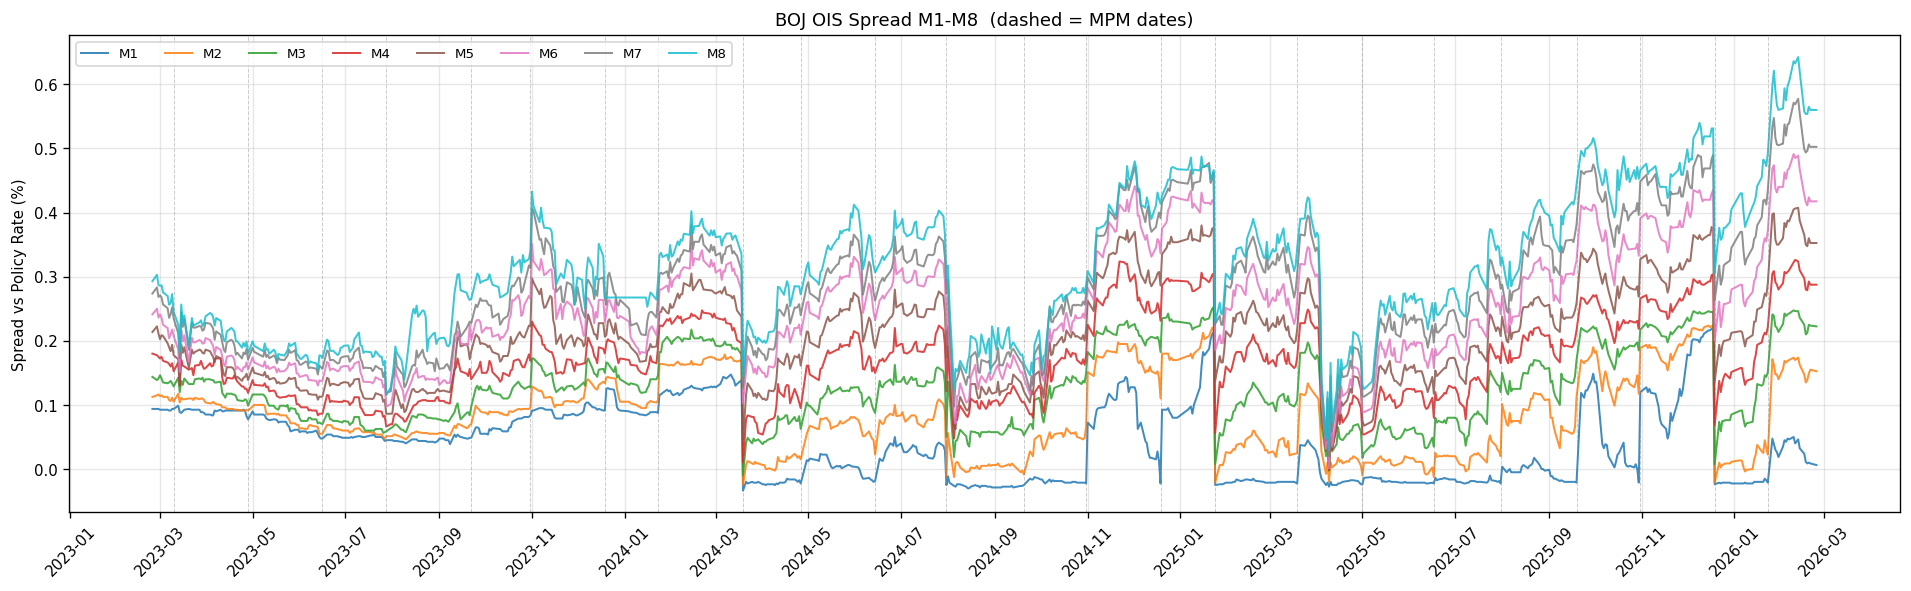

In [6]:
tab10 = plt.cm.tab10(np.linspace(0, 0.9, 8))
fig, ax = plt.subplots(figsize=(16, 5))
for i in range(1, 9):
    ax.plot(df_feat['Date'], df_feat[f'M{i}_spread'],
            label=f'M{i}', color=tab10[i-1], linewidth=1.2, alpha=0.85)
for d in meeting_dates:
    ax.axvline(d, color='gray', linestyle='--', linewidth=0.6, alpha=0.4)
ax.set_title('BOJ OIS Spread M1-M8  (dashed = MPM dates)')
ax.set_ylabel('Spread vs Policy Rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend(ncol=8, loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Figure 2/3: 予測水準 vs 実測水準（全期間）

- **黒線**: 実際の M{n}_spread 水準
- **橙線（薄）**: in-sample 予測水準（2024年以前）
- **橙線（濃）**: out-of-sample 予測水準（2024年以降）
- **赤点線**: 未来予測（データ末尾から h 日後）
- グレー縦線: MPM 日付

IC はウォークフォワードの out-of-sample 期間で計算した値。

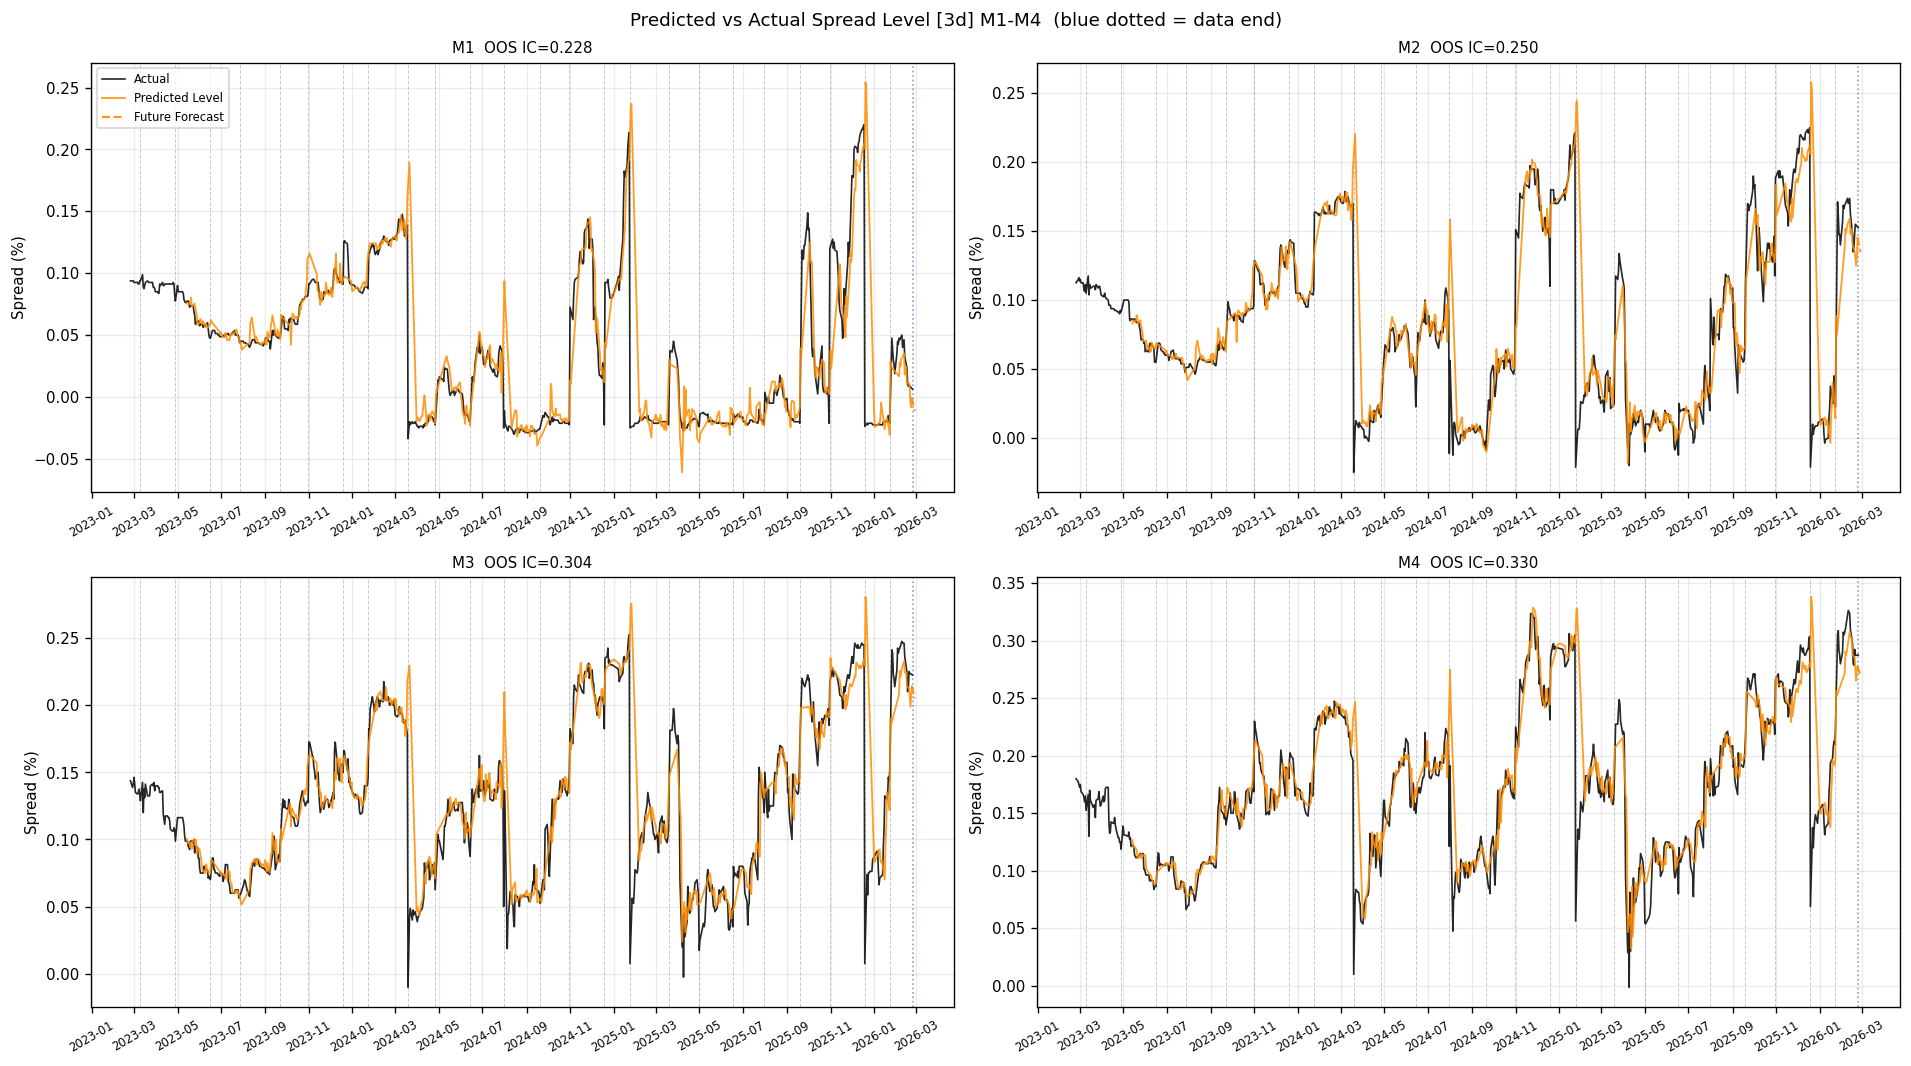

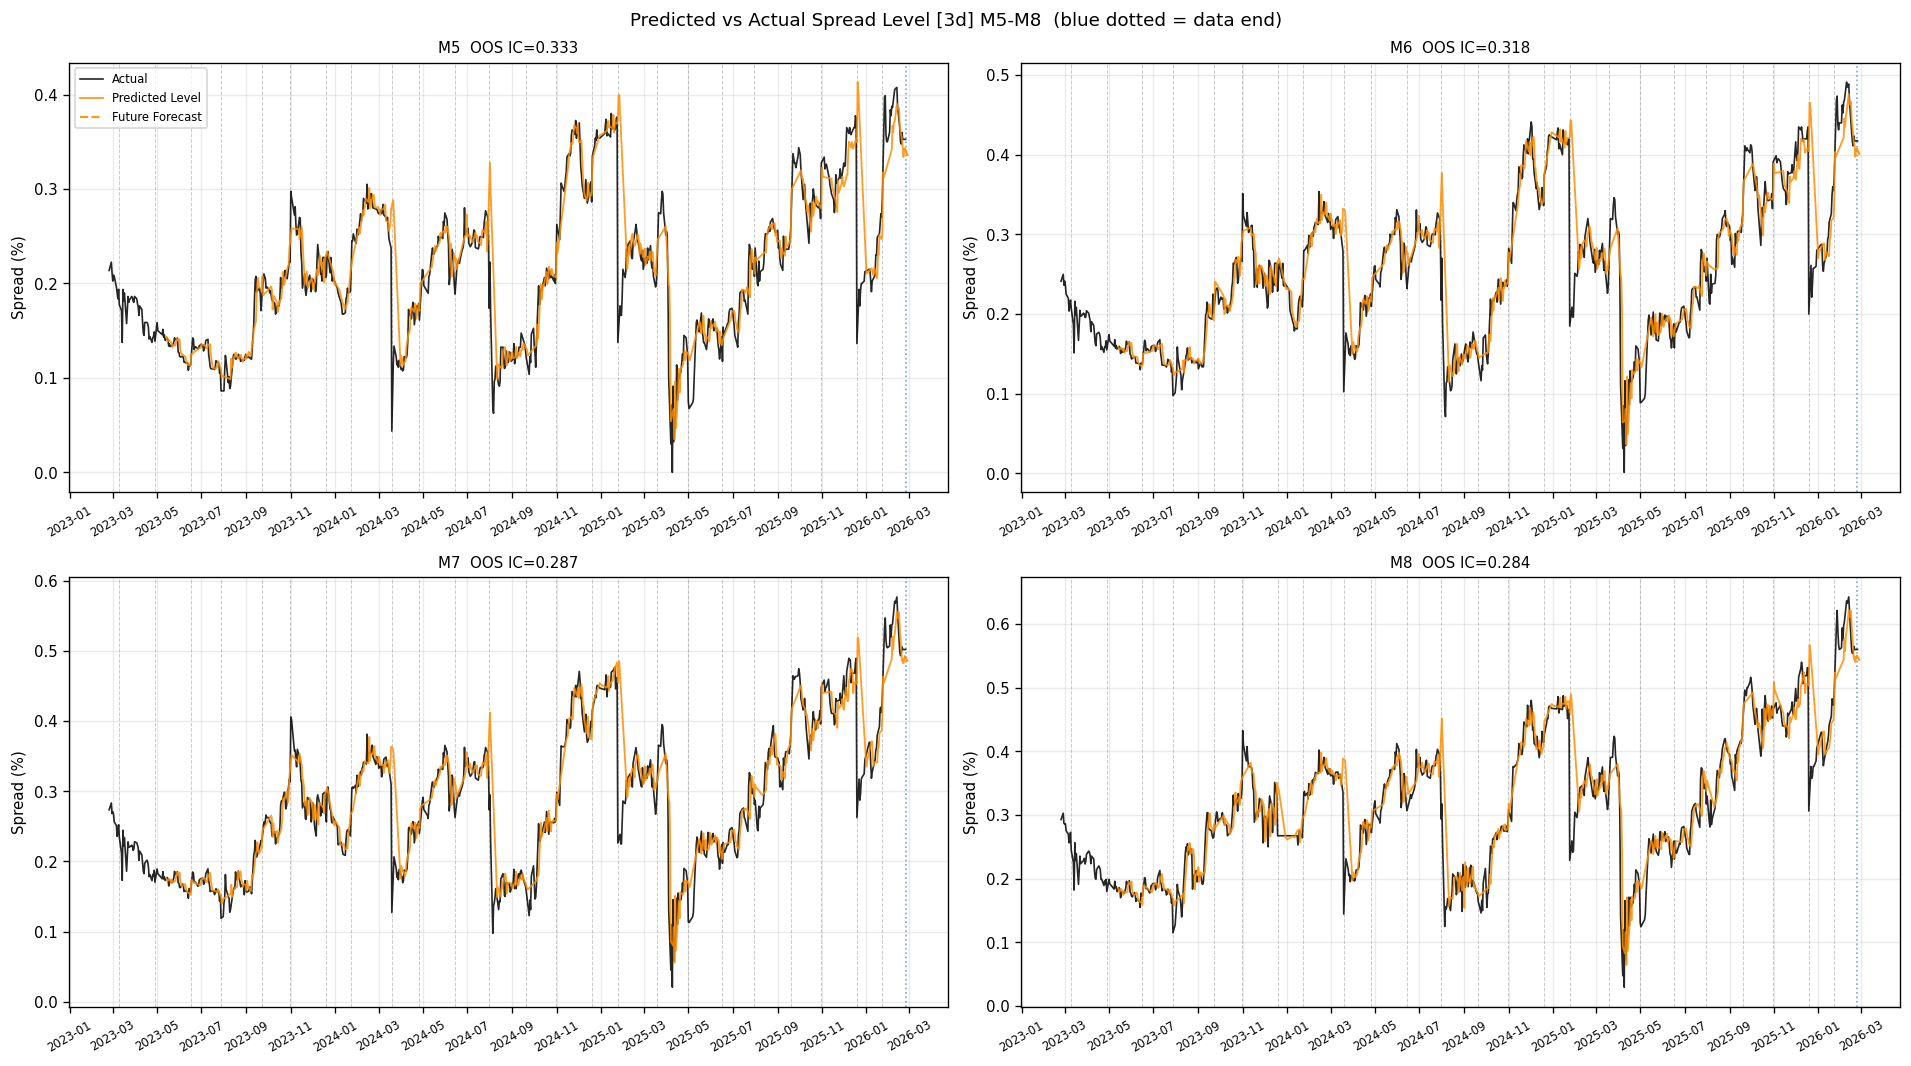

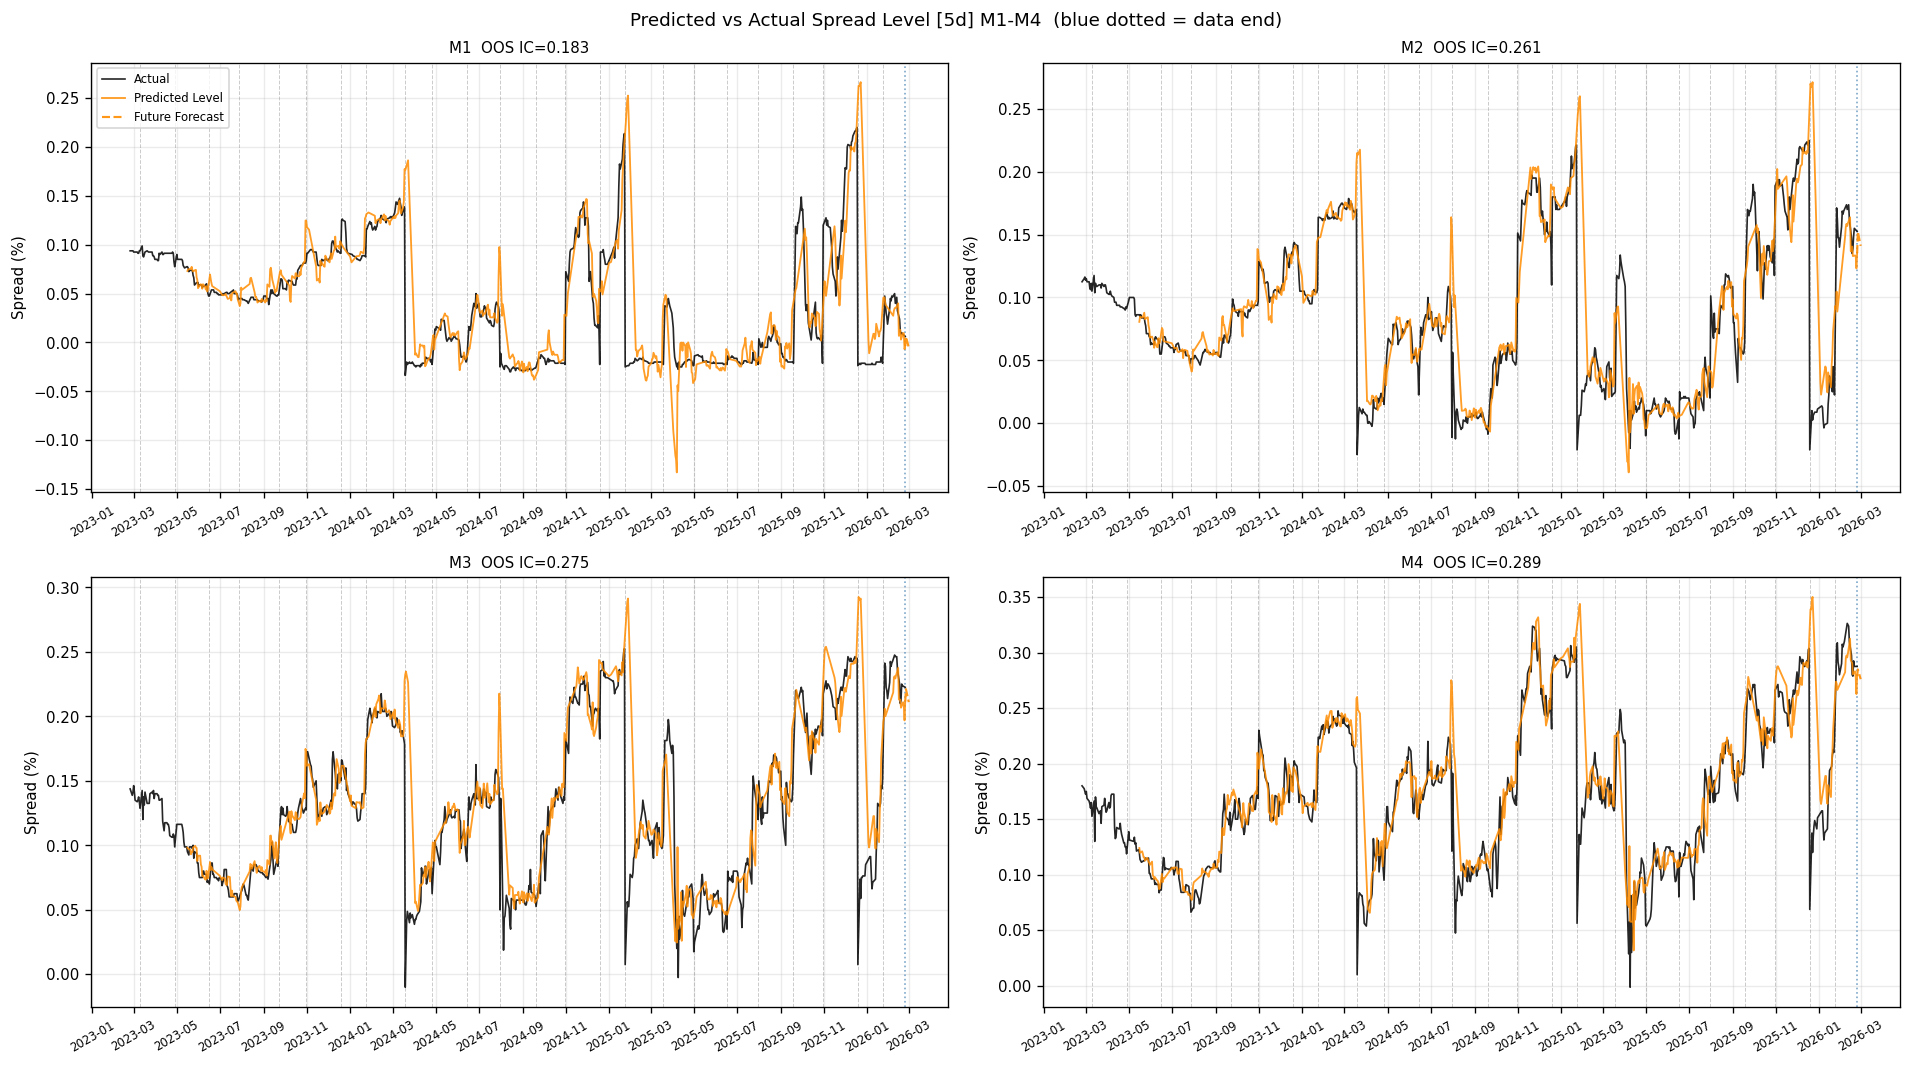

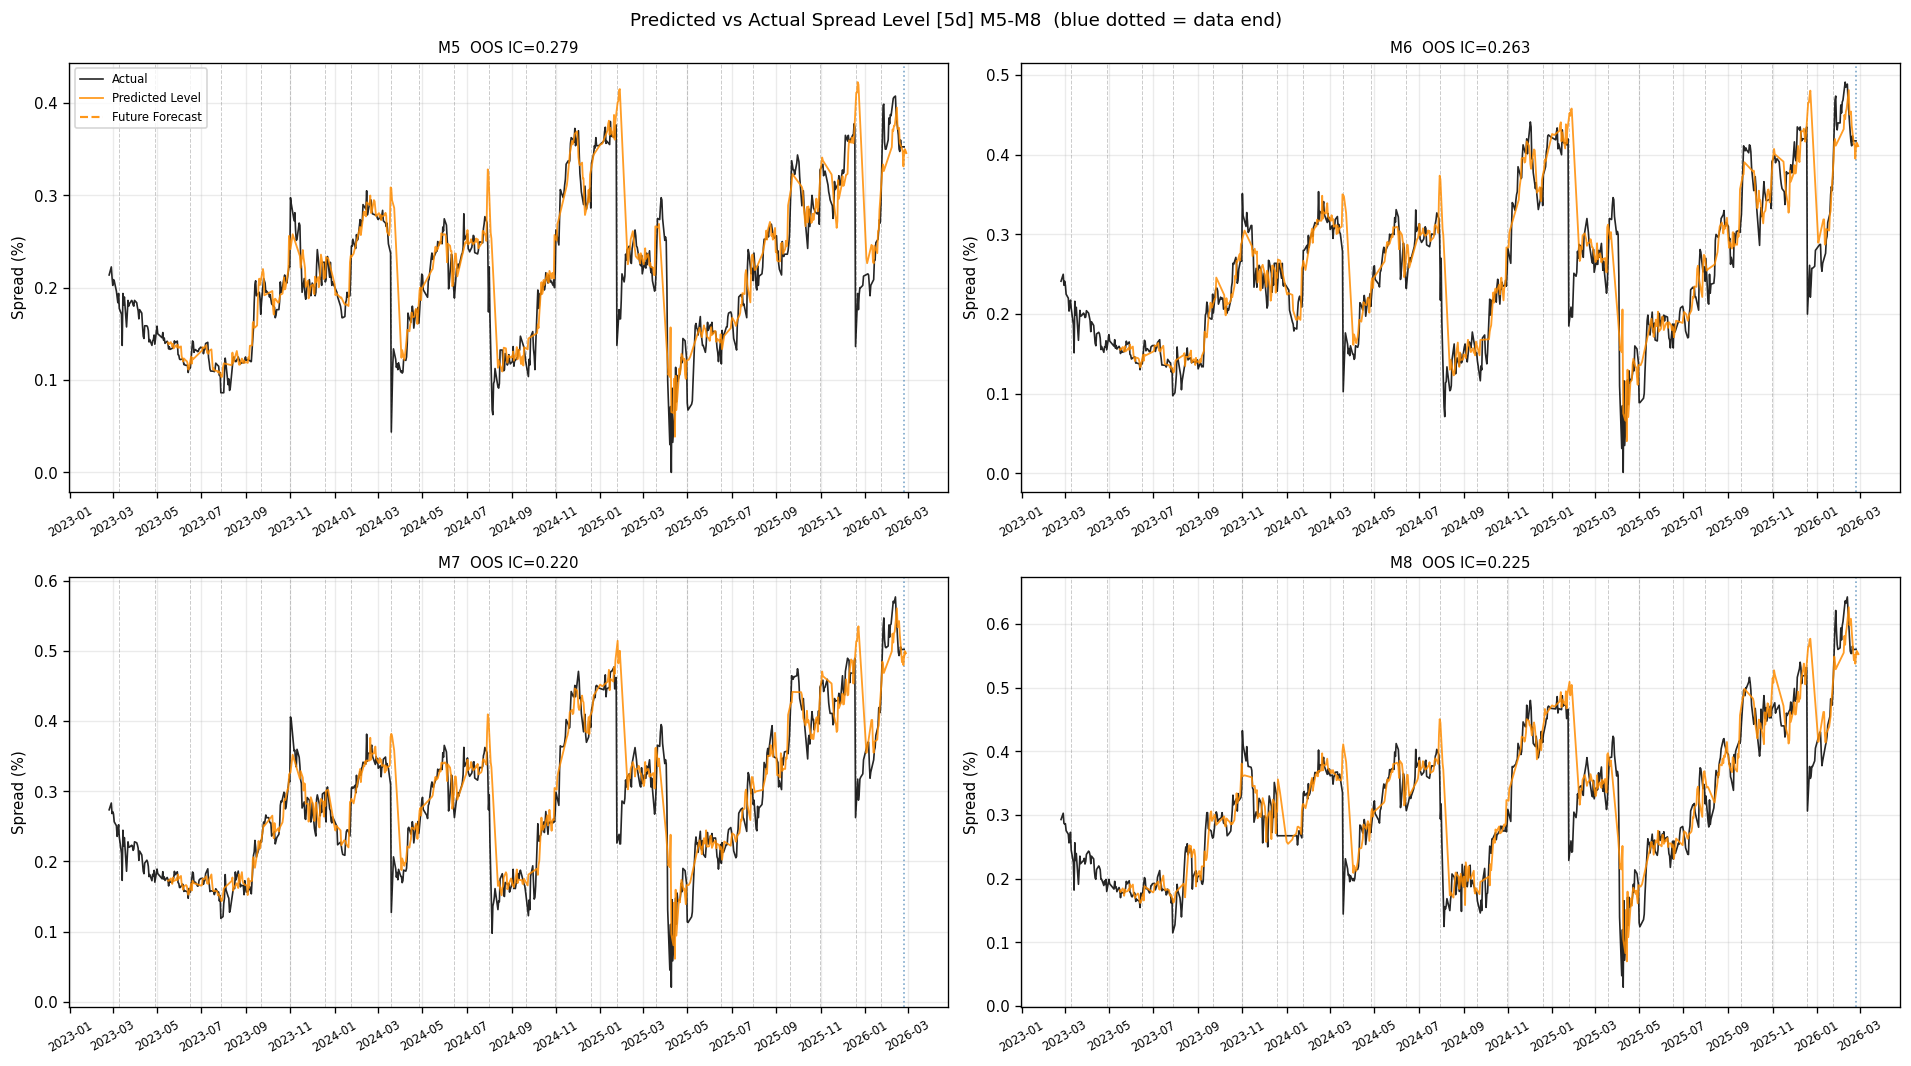

In [7]:
def add_vlines(ax, meeting_dates, xmin, xmax):
    for d in meeting_dates:
        if xmin <= d <= xmax:
            ax.axvline(d, color='gray', linestyle='--', linewidth=0.6, alpha=0.4)


def plot_level_grid(mi_list, h, title_suffix=''):
    pred_df_h = all_pred_dfs[h]
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    axes = axes.flatten()

    last_actual_date = actual_spread['Date'].max()

    for idx, mi in enumerate(mi_list):
        ax = axes[idx]
        spread_col = f'M{mi}_spread'

        # 実測水準（黒線）
        ax.plot(actual_spread['Date'], actual_spread[spread_col],
                color='black', linewidth=1.0, alpha=0.85, label='Actual', zorder=3)

        sub = pred_df_h[pred_df_h['Meeting_Index'] == mi].dropna(subset=['Pred_Level'])

        # 比較可能な予測（Plot_Date <= last_actual_date）: オレンジ実線
        hist = sub[sub['Plot_Date'] <= last_actual_date]
        if len(hist) > 0:
            ax.plot(hist['Plot_Date'], hist['Pred_Level'],
                    color='darkorange', linewidth=1.1, alpha=0.85,
                    label='Predicted Level', zorder=4)

        # 未来予測（Plot_Date > last_actual_date）: オレンジ点線で延長
        fut = sub[sub['Plot_Date'] > last_actual_date]
        if len(fut) > 0:
            if len(hist) > 0:
                connect = hist.iloc[[-1]]
                fut = pd.concat([connect, fut], ignore_index=True)
            ax.plot(fut['Plot_Date'], fut['Pred_Level'],
                    color='darkorange', linewidth=1.3, linestyle='--', alpha=0.9,
                    label='Future Forecast', zorder=5)

        # データ末尾に青縦線
        ax.axvline(last_actual_date, color='steelblue', linestyle=':', linewidth=1.0, alpha=0.7)

        # 会合縦線
        xmin = actual_spread['Date'].min()
        xmax = sub['Plot_Date'].max() if len(sub) > 0 else last_actual_date
        add_vlines(ax, meeting_dates, xmin, xmax)

        wf_mi = wf_results[h][wf_results[h]['Meeting_Index'] == mi]
        ic_str = ''
        if len(wf_mi) >= 2:
            ic = calculate_metrics(wf_mi['Actual'], wf_mi['Pred'])['IC']
            ic_str = f'  OOS IC={ic:.3f}'

        ax.set_title(f'M{mi}{ic_str}', fontsize=9)
        ax.set_ylabel('Spread (%)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, fontsize=7)
        ax.grid(True, alpha=0.25)
        if idx == 0:
            ax.legend(fontsize=7, loc='upper left')

    fig.suptitle(f'Predicted vs Actual Spread Level [{h}d]{title_suffix}  (blue dotted = data end)', fontsize=11)
    plt.tight_layout()
    plt.show()


for h in horizons:
    plot_level_grid([1, 2, 3, 4], h, ' M1-M4')
    plot_level_grid([5, 6, 7, 8], h, ' M5-M8')

## Figure 4: フォールド別 IC サマリー（out-of-sample）

In [8]:
rows = []
for h in horizons:
    for fold in sorted(wf_results[h]['Fold'].unique()):
        f_data = wf_results[h][wf_results[h]['Fold'] == fold]
        m = calculate_metrics(f_data['Actual'], f_data['Pred'])
        rows.append({
            'Horizon': f'{h}d', 'Fold': fold, 'N': len(f_data),
            'Period': f"{f_data['Date'].min().strftime('%Y-%m-%d')}~{f_data['Date'].max().strftime('%Y-%m-%d')}",
            'IC': round(m['IC'], 4),
            'DA_Large': round(m['Direction_Accuracy_LargeMove'], 4),
        })
print(pd.DataFrame(rows).to_string(index=False))

Horizon  Fold   N                Period      IC  DA_Large
     3d     0 384 2024-01-04~2024-04-02  0.0796    0.6979
     3d     1 392 2024-04-03~2024-07-01  0.2378    0.7755
     3d     2 384 2024-07-02~2024-09-19  0.0194    0.5000
     3d     3 400 2024-10-01~2024-12-27  0.4521    0.8041
     3d     4 360 2024-12-30~2025-03-28  0.5222    0.9000
     3d     5 400 2025-03-31~2025-06-27  0.4789    0.7400
     3d     6 400 2025-06-30~2025-09-18  0.4023    0.8673
     3d     7 392 2025-09-30~2025-12-18  0.3571    0.7010
     3d     8 216 2025-12-29~2026-02-18  0.5390    0.7358
     5d     0 384 2024-01-04~2024-04-02  0.0093    0.8854
     5d     1 392 2024-04-03~2024-07-01  0.3115    0.8673
     5d     2 384 2024-07-02~2024-09-19 -0.0044    0.3438
     5d     3 400 2024-10-01~2024-12-27  0.2552    0.7423
     5d     4 360 2024-12-30~2025-03-28  0.4403    0.8222
     5d     5 400 2025-03-31~2025-06-27  0.5751    0.7551
     5d     6 400 2025-06-30~2025-09-18  0.2760    0.7100
     5d     7 